# Byte vs. codepoint n-grams -- Baldwin & Lui (2010)

A fourth, independent comparison for the same dialect/language-ID task,
based on **Baldwin & Lui, "Language Identification: The Long and the
Short of the Matter"** (NAACL 2010) --
[aclanthology.org/N10-1027](https://aclanthology.org/N10-1027/).

**What the paper actually did** (read in full before writing this
notebook): compared two document representations -- **byte n-grams**
(extracted directly from the raw UTF-8 byte stream, no encoding
detection needed) vs. **codepoint n-grams** (character n-grams, requires
knowing the text encoding) -- at n=1,2,3, across 7 classifiers (cosine/
skew-divergence/out-of-place nearest-neighbor and nearest-prototype,
naive Bayes, linear SVM), evaluated over three real datasets. Their
headline findings: **byte n-grams consistently beat or matched codepoint
n-grams** (so skipping encoding detection isn't just simpler, it's also
more accurate), **bigrams/trigrams beat unigrams** with little
difference between the two, and the two most consistently strong models
were **cosine-similarity 1-nearest-neighbor and linear SVM** -- simple
methods beating more complex ones, a result that still shapes production
LID systems today (`langid.py`, fastText's own `lid.176` model, etc. are
all still n-gram + linear/Bayes, not deep nets).

**This notebook's design, per spec**: same byte-vs-codepoint,
bigram-vs-trigram comparison, but a different (larger, more modern)
model roster -- weighted cosine k-NN (k=5, not the paper's 1-NN),
random forest, a small custom attention neural net, naive Bayes, and
SVM with both linear and RBF kernels. **Same script-gating as the rest
of this project** (`code_switch`/`other` decided by the deterministic
regex, never modeled) -- shrinks each classification problem exactly
the way the paper predicts helps most: fewer classes, per-group.

**Class balancing**: each group's training features are balanced via
**SMOTE** (Chawla et al. 2002) before fitting the 5 vector-based
classifiers. `imbalanced-learn` isn't installable in this sandboxed
environment (no outbound network access), so SMOTE is implemented here
from scratch, following the original algorithm exactly (for each
minority-class sample needed, interpolate between a real minority-class
point and one of its *k* nearest same-class neighbors) -- operates
directly on the sparse TF-IDF matrices, no densification. The neural net
uses **class-weighted loss** instead of SMOTE for the same effect --
SMOTE interpolates in a continuous feature space, which doesn't have a
sensible meaning for the net's discrete n-gram *token-id sequence*
input (there's no way to "interpolate" between two token-id sequences
and get another valid one) -- flagged here, not silently glossed over.

Run this notebook's kernel from the GPU venv (`ai-gpu`).


In [1]:
import re
import time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch
import torch.nn as nn
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.svm import SVC
from torch.utils.data import DataLoader, Dataset
import json
from pathlib import Path

ROOT = Path.cwd().resolve().parents[1]  # project root, when running from Dialect_Identification/notebooks/
DATA_DIR = ROOT / "Dialect_Identification" / "data"

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


## 1. Script-gating + data loading (same convention as the rest of this project)

In [2]:
_MENTION_WITH_FRAGMENT_RE = re.compile(r"\[MENTION\](\s*-[^\s]{1,10})?")
_URL_RE = re.compile(r"\[URL\]")
_INLINE_WHITESPACE_RE = re.compile(r"[ \t]+")
_ARABIC_RE = re.compile(r"[\u0600-\u06ff\u0750-\u077f\u08a0-\u08ff\ufb50-\ufdff\ufe70-\ufeff]")
_LATIN_RE = re.compile(r"[a-zA-Z\u00c0-\u024f]")

ARABIC_CLASSES = ["msa", "darija"]
LATIN_CLASSES = ["arabize", "french", "english"]


def clean_for_classification(text: str) -> str:
    text = _MENTION_WITH_FRAGMENT_RE.sub("", text)
    text = _URL_RE.sub("", text)
    return _INLINE_WHITESPACE_RE.sub(" ", text).strip()


def script_of(text: str) -> str:
    has_ar = bool(_ARABIC_RE.search(text))
    has_lat = bool(_LATIN_RE.search(text))
    if has_ar and has_lat:
        return "mixed"
    if has_ar:
        return "arabic"
    if has_lat:
        return "latin"
    return "other"


def load_group(split: str, group: str) -> tuple[list[str], list[str]]:
    classes = ARABIC_CLASSES if group == "arabic" else LATIN_CLASSES
    texts, labels = [], []
    with (DATA_DIR / f"{split}.jsonl").open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            r = json.loads(line)
            if r["label"] not in classes:
                continue
            cleaned = clean_for_classification(r["text"])
            if script_of(cleaned) != group:
                continue
            texts.append(cleaned)
            labels.append(r["label"])
    return texts, labels


groups = {}
for group in ("arabic", "latin"):
    train_texts, train_labels = load_group("train", group)
    test_texts, test_labels = load_group("test", group)
    groups[group] = dict(train_texts=train_texts, train_labels=train_labels,
                          test_texts=test_texts, test_labels=test_labels)
    print(f"{group}: train={len(train_texts):,}  test={len(test_texts):,}  "
          f"train label counts={Counter(train_labels)}")


arabic: train=6,660  test=1,665  train label counts=Counter({'darija': 4493, 'msa': 2167})


latin: train=4,563  test=1,142  train label counts=Counter({'arabize': 2482, 'french': 1658, 'english': 423})


## 2. Byte vs. codepoint n-gram featurization

`to_byte_string()` re-encodes text so each **byte** maps to exactly one
Python `str` character (`latin1` is a bijective 1-byte<->1-codepoint
mapping) -- this lets `sklearn`'s standard `analyzer="char"` vectorizer
extract *byte* n-grams for free by just running it over this re-encoded
string instead of the original text. Codepoint n-grams use the original
Unicode text directly, unchanged.

In [3]:
def to_byte_string(text: str) -> str:
    return text.encode("utf-8", errors="ignore").decode("latin1")


FEATURE_VARIANTS = [
    ("byte", 2, "byte_bigram"),
    ("byte", 3, "byte_trigram"),
    ("char", 2, "char_bigram"),
    ("char", 3, "char_trigram"),
]

VOCAB_CAP = 3000  # max_features per (group, feature_type) vectorizer


def make_vectorizer(kind: str, n: int) -> TfidfVectorizer:
    return TfidfVectorizer(analyzer="char", ngram_range=(n, n), max_features=VOCAB_CAP, min_df=2)


def prep_texts(texts: list[str], kind: str) -> list[str]:
    return [to_byte_string(t) for t in texts] if kind == "byte" else texts


## 3. SMOTE, implemented from scratch

`imbalanced-learn` isn't installable here (no outbound network in this
sandbox) -- this is the actual SMOTE algorithm (Chawla et al. 2002), not
a simplification: for each class below the majority count, repeatedly
pick a real minority-class sample, find one of its *k* nearest
same-class neighbors, and generate a synthetic point at a random
position along the line segment between them. Operates on sparse
matrices throughout (`scipy.sparse`), matching the TF-IDF vectors it
will be applied to -- no densification.

In [4]:
def smote_balance(X: sp.csr_matrix, y: np.ndarray, k: int = 5, random_state: int = SEED):
    rng = np.random.RandomState(random_state)
    classes, counts = np.unique(y, return_counts=True)
    target = counts.max()

    X_parts, y_parts = [X], [y]
    for c, cnt in zip(classes, counts):
        n_needed = target - cnt
        if n_needed <= 0:
            continue
        X_c = X[y == c]
        if X_c.shape[0] < 2:
            idx = rng.randint(0, X_c.shape[0], size=n_needed)
            X_parts.append(X_c[idx])
            y_parts.append(np.full(n_needed, c))
            continue

        n_neighbors = min(k + 1, X_c.shape[0])  # +1: kneighbors includes the point itself
        nn_model = NearestNeighbors(n_neighbors=n_neighbors, metric="euclidean").fit(X_c)
        base_idx = rng.randint(0, X_c.shape[0], size=n_needed)
        _, neighbor_idx = nn_model.kneighbors(X_c[base_idx])

        synth_rows = []
        for i, b in enumerate(base_idx):
            candidates = neighbor_idx[i][1:]  # drop self (always nearest to itself)
            nb = candidates[rng.randint(0, len(candidates))] if len(candidates) else b
            gap = rng.uniform(0.0, 1.0)
            synth_rows.append(X_c[b] + gap * (X_c[nb] - X_c[b]))
        X_synth = sp.vstack(synth_rows).tocsr()

        X_parts.append(X_synth)
        y_parts.append(np.full(n_needed, c))

    X_bal = sp.vstack(X_parts).tocsr()
    y_bal = np.concatenate(y_parts)
    return X_bal, y_bal


## 4. Classifier-head neural net

Per spec, in order: **input layer** (n-gram token embedding) ->
**attention layer** (self-attention over the document's n-gram sequence)
-> **ReLU layer** -> **residual connection** -> **layer norm** ->
**classification head**. Uses the *same* vocabulary as that
feature-type's `TfidfVectorizer` (so results are comparable -- same
n-grams "known" either way), but as a discrete token-id **sequence**
(with repeats, in occurrence order, capped at `MAX_LEN`) rather than a
pooled count vector -- the sequence is what the attention layer needs.

In [5]:
MAX_LEN = 150


class NgramAttentionNet(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int, num_classes: int, num_heads: int = 4, dropout: float = 0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=0)  # +1: id 0 reserved for padding
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.relu = nn.ReLU()
        self.ffn = nn.Linear(embed_dim, embed_dim)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, ids: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        x = self.embedding(ids)                                                 # input layer
        attn_out, _ = self.attn(x, x, x, key_padding_mask=~mask, need_weights=False)  # attention layer
        h = self.relu(self.ffn(attn_out))                                       # relu layer
        x = self.norm(x + h)                                                    # residual connection + layer norm

        mask_f = mask.unsqueeze(-1).to(x.dtype)
        pooled = (x * mask_f).sum(1) / mask_f.sum(1).clamp(min=1.0)
        return self.head(pooled)                                                # classification head


def ngram_seq(s: str, n: int, vocab: dict[str, int], max_len: int = MAX_LEN) -> list[int]:
    toks = [s[i:i + n] for i in range(len(s) - n + 1)] if len(s) >= n else ([s] if s else [])
    ids = [vocab[t] + 1 for t in toks if t in vocab][:max_len]  # +1: id 0 reserved for padding
    return ids or [0]


class NgramSeqDataset(Dataset):
    def __init__(self, texts: list[str], labels: list[int], kind: str, n: int, vocab: dict[str, int]):
        prepped = prep_texts(texts, kind)
        self.rows = [(ngram_seq(s, n, vocab), y) for s, y in zip(prepped, labels)]

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        return self.rows[idx]


def make_collate(device):
    def collate(batch):
        seqs, labels = zip(*batch)
        max_len = max(len(s) for s in seqs)
        ids = torch.zeros(len(batch), max_len, dtype=torch.long)
        mask = torch.zeros(len(batch), max_len, dtype=torch.bool)
        for i, s in enumerate(seqs):
            ids[i, :len(s)] = torch.tensor(s, dtype=torch.long)
            mask[i, :len(s)] = True
        return ids.to(device), mask.to(device), torch.tensor(labels, dtype=torch.long).to(device)
    return collate


collate = make_collate(device)


def train_nn(train_texts, train_labels_id, test_texts, test_labels_id, kind, n, vocab, num_classes,
             epochs: int = 15, embed_dim: int = 64, lr: float = 1e-3, batch_size: int = 128):
    train_ds = NgramSeqDataset(train_texts, train_labels_id, kind, n, vocab)
    test_ds = NgramSeqDataset(test_texts, test_labels_id, kind, n, vocab)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=collate)

    # Class-weighted loss -- the balancing counterpart to SMOTE for this
    # model (see intro: SMOTE doesn't have a sensible meaning for discrete
    # token-id sequences).
    counts = np.bincount(train_labels_id, minlength=num_classes)
    class_weight = torch.tensor(counts.sum() / (num_classes * np.clip(counts, 1, None)), dtype=torch.float32).to(device)

    model = NgramAttentionNet(len(vocab), embed_dim, num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=class_weight)

    for _ in range(epochs):
        model.train()
        for ids, mask, labels in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(ids, mask), labels)
            loss.backward()
            optimizer.step()

    model.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for ids, mask, labels in test_loader:
            preds = model(ids, mask).argmax(dim=-1)
            all_true.extend(labels.tolist())
            all_pred.extend(preds.tolist())
    return all_true, all_pred


## 5. Run the full comparison

For every (script group x feature variant): build the TF-IDF vectorizer
+ SMOTE-balanced training matrix, fit the 5 vector-based classifiers,
train the neural net on the matching token-id sequences, evaluate all 6
on the same (unbalanced, real-distribution) test split.

In [6]:
def build_classical_models(k_neighbors: int = 5):
    return {
        "knn_cosine_w5": KNeighborsClassifier(n_neighbors=k_neighbors, metric="cosine", weights="distance"),
        "random_forest": RandomForestClassifier(max_depth=4, n_estimators=100, random_state=SEED),
        "naive_bayes": MultinomialNB(),
        "svm_linear": SVC(kernel="linear", random_state=SEED),
        "svm_rbf": SVC(kernel="rbf", random_state=SEED),
    }


results = []
timings = []

for group, gdata in groups.items():
    classes = ARABIC_CLASSES if group == "arabic" else LATIN_CLASSES
    label_to_id = {c: i for i, c in enumerate(classes)}
    y_train = np.array([label_to_id[l] for l in gdata["train_labels"]])
    y_test = np.array([label_to_id[l] for l in gdata["test_labels"]])

    for kind, n, feat_name in FEATURE_VARIANTS:
        t0 = time.time()
        vec = make_vectorizer(kind, n)
        X_train = vec.fit_transform(prep_texts(gdata["train_texts"], kind))
        X_test = vec.transform(prep_texts(gdata["test_texts"], kind))
        vocab = vec.vocabulary_

        X_train_bal, y_train_bal = smote_balance(X_train, y_train)

        for model_name, model in build_classical_models().items():
            model.fit(X_train_bal, y_train_bal)
            pred = model.predict(X_test)
            results.append({
                "group": group, "feature": feat_name, "model": model_name,
                "accuracy": accuracy_score(y_test, pred),
                "macro_f1": f1_score(y_test, pred, average="macro", zero_division=0),
            })

        nn_true, nn_pred = train_nn(
            gdata["train_texts"], y_train.tolist(), gdata["test_texts"], y_test.tolist(),
            kind, n, vocab, num_classes=len(classes),
        )
        results.append({
            "group": group, "feature": feat_name, "model": "attention_nn",
            "accuracy": accuracy_score(nn_true, nn_pred),
            "macro_f1": f1_score(nn_true, nn_pred, average="macro", zero_division=0),
        })

        print(f"{group:<7} {feat_name:<13} done in {time.time() - t0:.1f}s "
              f"(vocab={len(vocab)}, train_bal={X_train_bal.shape[0]})")

results_df = pd.DataFrame(results)
results_df


arabic  byte_bigram   done in 75.4s (vocab=1340, train_bal=8986)


arabic  byte_trigram  done in 109.2s (vocab=3000, train_bal=8986)


arabic  char_bigram   done in 84.3s (vocab=2623, train_bal=8986)


arabic  char_trigram  done in 88.2s (vocab=3000, train_bal=8986)


latin   byte_bigram   done in 27.6s (vocab=1898, train_bal=7446)


latin   byte_trigram  done in 30.0s (vocab=3000, train_bal=7446)


latin   char_bigram   done in 28.4s (vocab=1826, train_bal=7446)


latin   char_trigram  done in 29.3s (vocab=3000, train_bal=7446)


,group,feature,model,accuracy,macro_f1
0,arabic,byte_bigram,knn_cosine_w5,0.657658,0.652897
1,arabic,byte_bigram,random_forest,0.726727,0.650394
2,arabic,byte_bigram,naive_bayes,0.714114,0.702498
3,arabic,byte_bigram,svm_linear,0.767568,0.747443
4,arabic,byte_bigram,svm_rbf,0.792192,0.761769
5,arabic,byte_bigram,attention_nn,0.712312,0.690713
6,arabic,byte_trigram,knn_cosine_w5,0.631231,0.629401
7,arabic,byte_trigram,random_forest,0.742342,0.653241
8,arabic,byte_trigram,naive_bayes,0.796997,0.776430
9,arabic,byte_trigram,svm_linear,0.807207,0.787073


## 6. Comparison plots

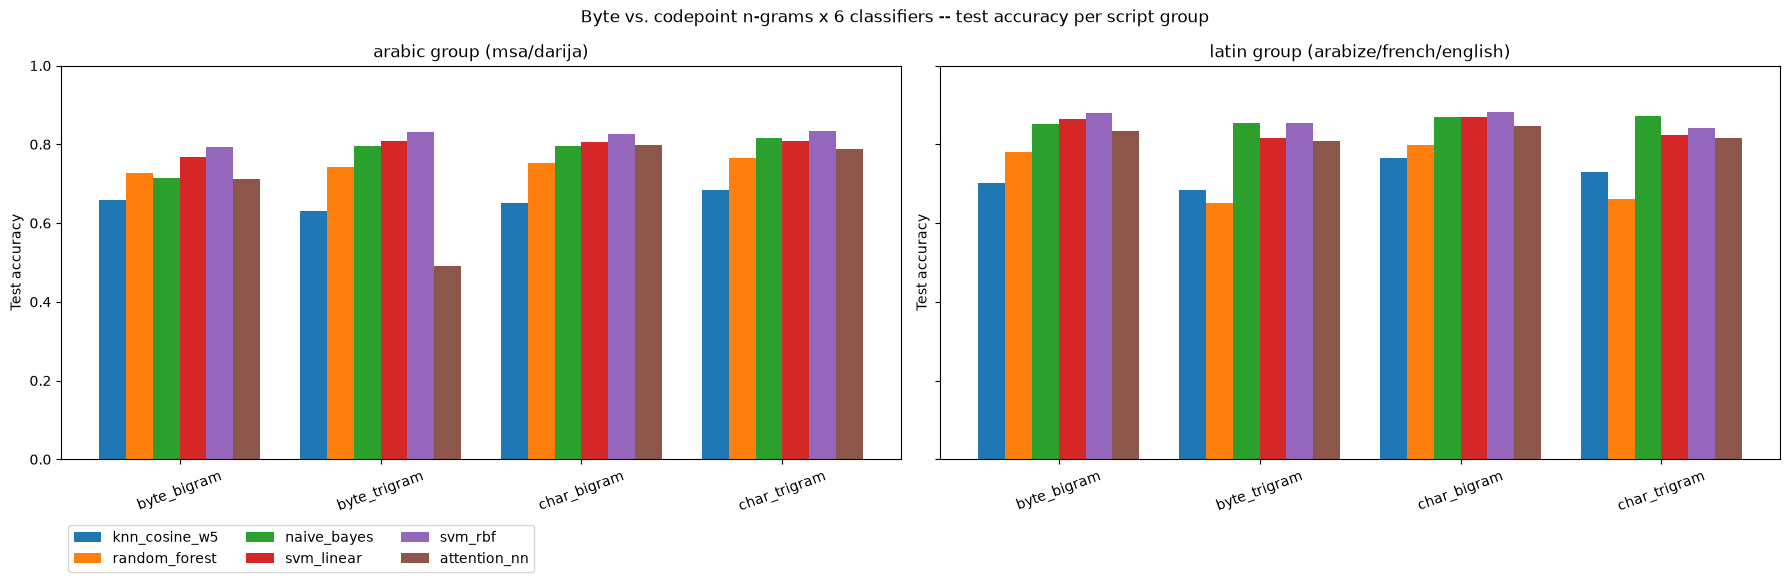

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
models_order = ["knn_cosine_w5", "random_forest", "naive_bayes", "svm_linear", "svm_rbf", "attention_nn"]
features_order = [f[2] for f in FEATURE_VARIANTS]
colors = plt.cm.tab10.colors

for ax, group in zip(axes, groups.keys()):
    sub = results_df[results_df["group"] == group]
    x = np.arange(len(features_order))
    width = 0.8 / len(models_order)
    for i, model_name in enumerate(models_order):
        vals = [sub[(sub["feature"] == f) & (sub["model"] == model_name)]["accuracy"].values[0] for f in features_order]
        ax.bar(x + i * width, vals, width, label=model_name, color=colors[i % len(colors)])
    ax.set_xticks(x + width * (len(models_order) - 1) / 2)
    ax.set_xticklabels(features_order, rotation=20)
    ax.set_title(f"{group} group ({'msa/darija' if group == 'arabic' else 'arabize/french/english'})")
    ax.set_ylabel("Test accuracy")
    ax.set_ylim(0, 1)

axes[0].legend(loc="upper left", bbox_to_anchor=(0, -0.15), ncol=3)
fig.suptitle("Byte vs. codepoint n-grams x 6 classifiers -- test accuracy per script group")
plt.tight_layout()
plt.show()


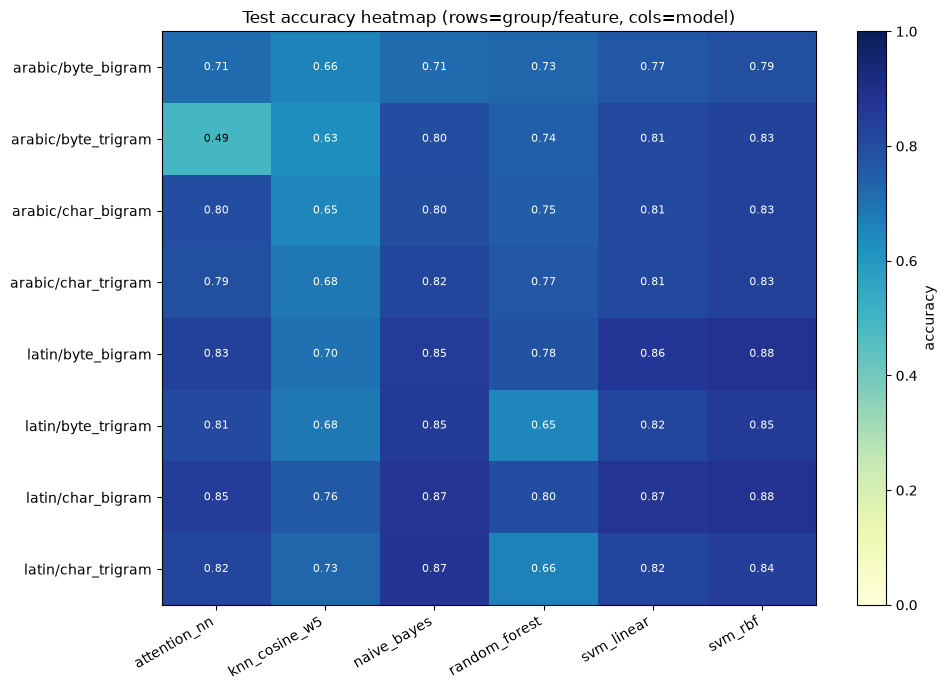

In [8]:
pivot = results_df.pivot_table(index=["group", "feature"], columns="model", values="accuracy")
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(pivot.values, cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"{g}/{f}" for g, f in pivot.index])
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center",
                 color="white" if pivot.values[i, j] > 0.6 else "black", fontsize=8)
ax.set_title("Test accuracy heatmap (rows=group/feature, cols=model)")
fig.colorbar(im, ax=ax, label="accuracy")
plt.tight_layout()
plt.show()


## 7. Byte vs. codepoint, directly (Baldwin & Lui's actual headline comparison)

Averaged across both n-gram orders, both script groups, and all 6
models -- the same comparison the paper's abstract leads with.

In [9]:
results_df["token_kind"] = results_df["feature"].str.split("_").str[0]
comparison = results_df.groupby("token_kind")["accuracy"].agg(["mean", "std", "count"])
print(comparison)
print(f"\nByte {'beats' if comparison.loc['byte', 'mean'] > comparison.loc['char', 'mean'] else 'loses to'} "
      f"codepoint by {abs(comparison.loc['byte', 'mean'] - comparison.loc['char', 'mean']):.4f} "
      f"mean accuracy across all {len(results_df)} (group, feature, model) runs.")


                mean       std  count
token_kind                           
byte        0.760305  0.092953     24
char        0.795928  0.063571     24

Byte loses to codepoint by 0.0356 mean accuracy across all 48 (group, feature, model) runs.
